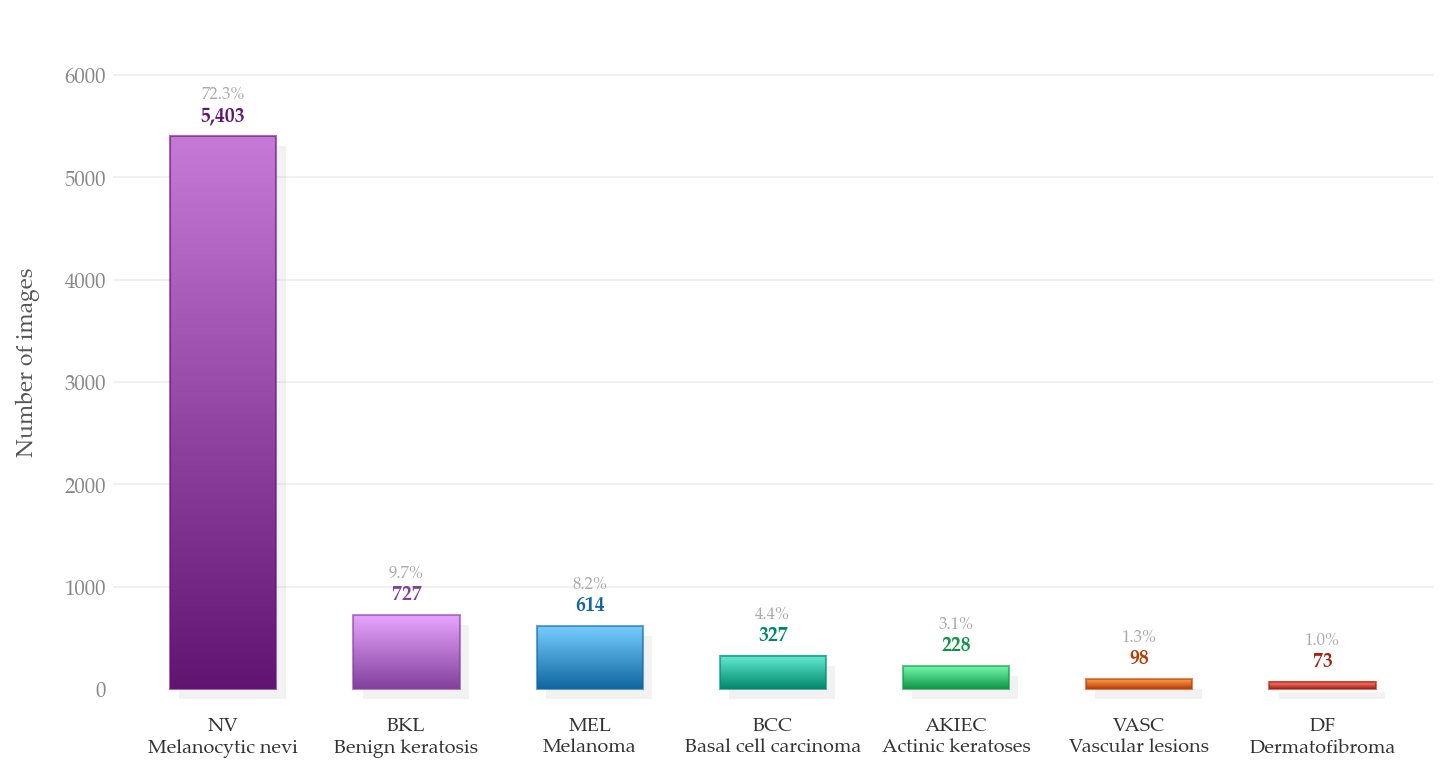

In [6]:
"""
HAM10000 Class Distribution Plot — Final
==========================================
Publication-quality figure for thesis inclusion.
White background version — paste into your thesis plots notebook.
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
from pathlib import Path

# ── Configuration ─────────────────────────────────────────────────────────────

META_PATH = Path("../data/processed/HAM10000/one_image_per_lesion/HAM10000_metadata_one_per_lesion.csv")

CLASS_FULL_NAMES = {
    "nv":    "Melanocytic nevi",
    "mel":   "Melanoma",
    "bkl":   "Benign keratosis",
    "bcc":   "Basal cell carcinoma",
    "akiec": "Actinic keratoses",
    "vasc":  "Vascular lesions",
    "df":    "Dermatofibroma",
}

CLASS_SHORT = {
    "nv":    "NV",
    "mel":   "MEL",
    "bkl":   "BKL",
    "bcc":   "BCC",
    "akiec": "AKIEC",
    "vasc":  "VASC",
    "df":    "DF",
}

# Jewel tones — vivid but not garish on white paper
COLOURS = [
    "#7B2D8B",   # deep violet
    "#9B59B6",   # amethyst
    "#2980B9",   # rich blue
    "#16A085",   # teal
    "#27AE60",   # emerald
    "#D35400",   # burnt orange
    "#C0392B",   # deep red
]

plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Palatino", "Palatino Linotype", "Book Antiqua", "DejaVu Serif"],
    "font.size":          11,
    "axes.labelsize":     11,
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   False,
    "axes.spines.bottom": False,
})

# ── Load and prepare ───────────────────────────────────────────────────────────

df     = pd.read_csv(META_PATH)
counts = df["dx"].value_counts()

ordered_keys    = sorted(CLASS_FULL_NAMES.keys(), key=lambda k: counts.get(k, 0), reverse=True)
ordered_short   = [CLASS_SHORT[k] for k in ordered_keys]
ordered_full    = [CLASS_FULL_NAMES[k] for k in ordered_keys]
ordered_counts  = [counts.get(k, 0) for k in ordered_keys]
ordered_colours = [COLOURS[i] for i in range(len(ordered_keys))]
total           = sum(ordered_counts)

# ── Plot ───────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

x = np.arange(len(ordered_keys))
BAR_WIDTH      = 0.58
GRADIENT_STEPS = 200

for i, (xi, count, colour) in enumerate(zip(x, ordered_counts, ordered_colours)):
    base_rgb  = np.array(mcolors.to_rgb(colour))
    light_rgb = np.clip(base_rgb + 0.30, 0, 1)   # lighter top
    dark_rgb  = np.clip(base_rgb - 0.10, 0, 1)   # darker base
    bar_left  = xi - BAR_WIDTH / 2
    step_h    = count / GRADIENT_STEPS

    # Gradient fill — stack of thin rectangles dark→light bottom→top
    for s in range(GRADIENT_STEPS):
        t        = s / GRADIENT_STEPS
        colour_s = (1 - t) * dark_rgb + t * light_rgb
        ax.add_patch(mpatches.FancyBboxPatch(
            (bar_left, s * step_h), BAR_WIDTH, step_h + 0.5,
            boxstyle="square,pad=0",
            facecolor=colour_s, edgecolor="none", zorder=3,
        ))

    # Crisp coloured border
    ax.add_patch(mpatches.FancyBboxPatch(
        (bar_left, 0), BAR_WIDTH, count,
        boxstyle="square,pad=0",
        facecolor="none",
        edgecolor=mcolors.to_hex(dark_rgb),
        linewidth=1.0, zorder=5, alpha=0.6,
    ))

    # Soft grey drop shadow
    ax.add_patch(mpatches.FancyBboxPatch(
        (bar_left + 0.05, -100), BAR_WIDTH, count,
        boxstyle="square,pad=0",
        facecolor="#bbbbbb", edgecolor="none",
        alpha=0.18, zorder=2,
    ))

# Subtle horizontal grid
for y in range(1000, max(ordered_counts) + 1000, 1000):
    ax.axhline(y, color="#eeeeee", linewidth=0.8, zorder=1)

# Count and percentage labels above each bar
for xi, count, colour in zip(x, ordered_counts, ordered_colours):
    base_rgb = np.array(mcolors.to_rgb(colour))
    dark_rgb = np.clip(base_rgb - 0.10, 0, 1)

    ax.text(xi, count + 90, f"{count:,}",
            ha="center", va="bottom",
            fontsize=9.5, fontweight="bold",
            color=mcolors.to_hex(dark_rgb), zorder=6)

    ax.text(xi, count + 320, f"{100 * count / total:.1f}%",
            ha="center", va="bottom",
            fontsize=8, color="#aaaaaa", zorder=6)

# X-axis: bold abbreviation + italic full name on second line
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{s}\n{f}" for s, f in zip(ordered_short, ordered_full)],
    fontsize=9.5, color="#333333", ha="center",
)

ax.set_ylabel("Number of images", labelpad=12, color="#555555", fontsize=11)
ax.set_ylim(-200, max(ordered_counts) * 1.22)
ax.set_xlim(-0.6, len(ordered_keys) - 0.4)
ax.tick_params(axis="both", which="both", length=0)
ax.yaxis.set_tick_params(labelcolor="#888888")

plt.tight_layout(pad=1.8)

# ── Save ───────────────────────────────────────────────────────────────────────

# out_path = Path("../figures/ham10000_class_distribution.pdf")
# out_path.parent.mkdir(parents=True, exist_ok=True)
# plt.savefig(out_path, facecolor="white")
# print(f"Saved → {out_path}")

# plt.show()